In [1]:
!pip install pandas matplotlib seaborn

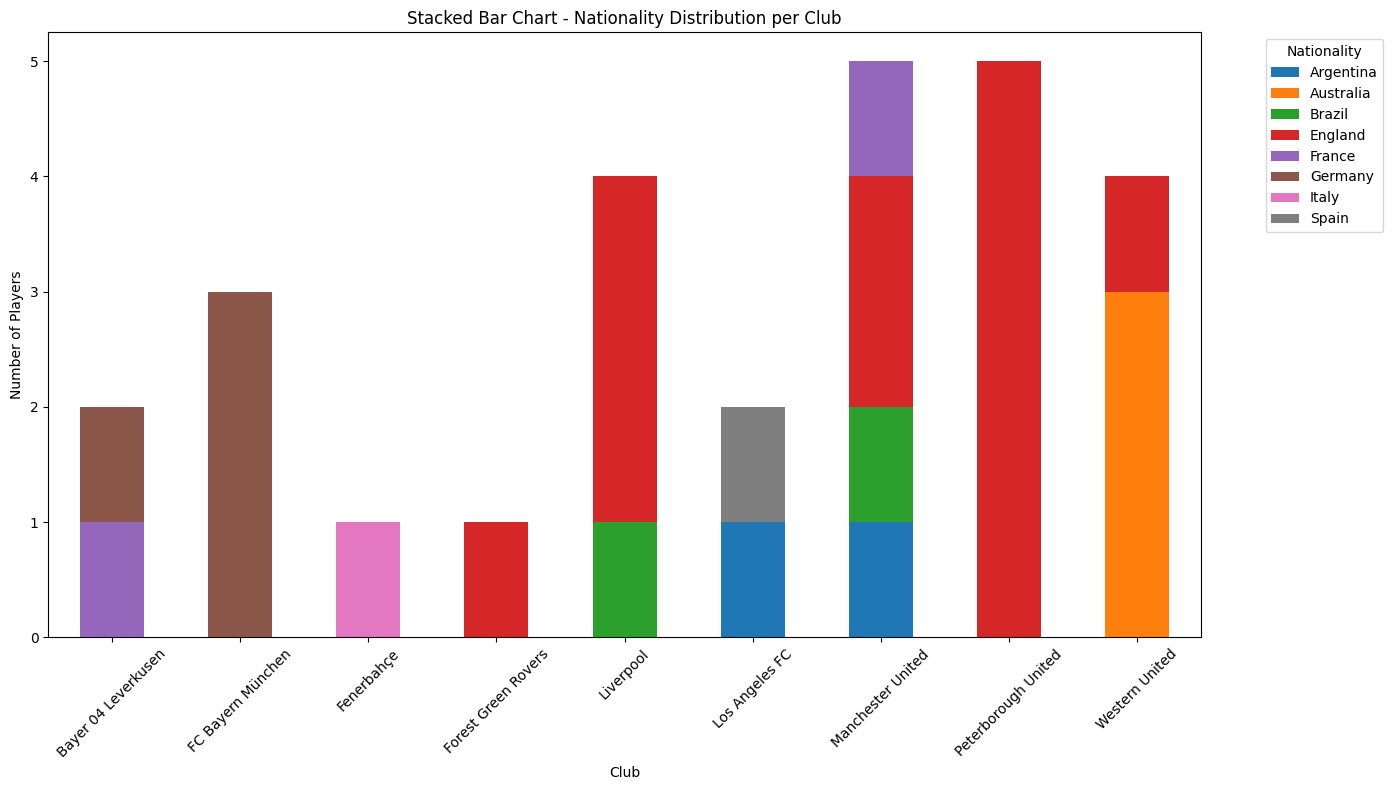

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("/content/clean_players.csv")

df = df[['club_name', 'nationality_name']]

df = df.dropna()

df = df.sample(n=1000, random_state=42)

top_clubs = df['club_name'].value_counts().head(10).index
top_nations = df['nationality_name'].value_counts().head(10).index

df_filtered = df[
    (df['club_name'].isin(top_clubs)) &
    (df['nationality_name'].isin(top_nations))
]

pivot = pd.crosstab(df_filtered['club_name'], df_filtered['nationality_name'])

pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8)
)

plt.title('Stacked Bar Chart - Nationality Distribution per Club')
plt.xlabel('Club')
plt.ylabel('Number of Players')
plt.legend(title='Nationality', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [3]:
!pip install pandas plotly

In [5]:
!pip install pandas plotly
import pandas as pd
import plotly.express as px
from google.colab import files

df = pd.read_csv("/content/clean_players.csv")
df = df[['club_name', 'nationality_name']].dropna()

df = df.sample(n=1000, random_state=42)

top_clubs = df['club_name'].value_counts().head(10).index
top_nations = df['nationality_name'].value_counts().head(10).index

df_filtered = df[
    (df['club_name'].isin(top_clubs)) &
    (df['nationality_name'].isin(top_nations))
]

grouped = df_filtered.groupby(['club_name', 'nationality_name']).size().reset_index(name='count')

fig = px.bar(
    grouped,
    x='club_name',
    y='count',
    color='nationality_name',
    title='Interactive Stacked Bar - Nationality Distribution per Club',
)

fig.update_layout(
    xaxis_title="Club",
    yaxis_title="Number of Players",
    legend_title="Nationality",
    barmode='stack'
)

fig.show()